# Pearson approximation loss in EXFOR→ENDF Legendre sampling

Compare two parquets produced by `scripts/exfor_to_endf_sampling_v2.py`:

- `legendre_coefficients_all_samples.parquet` — the Cholesky-regenerated samples that the pipeline writes by default in two-pass mode. They are multivariate Gaussian by construction (drawn from `cov_combined = corr_kw × outer(std_perbin, std_perbin)`).
- `legendre_coefficients_full_correlations.parquet` — the raw multi-bin Monte Carlo samples from the kernel-weight pass, written when `SAVE_FULL_CORRELATION_SAMPLES = True`. They carry the full joint distribution from shared-perturbation coupling.

The notebook quantifies how much the Gaussian step distorts the joint distribution of the Legendre coefficients.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

In [2]:
# Edit RUN_DIR to point at the rerun output directory.
RUN_DIR = Path('/share_snc/snc/JuanMonleon/ENDF_samples/new_test_44')

PARQUETS = {
    'gaussian':          RUN_DIR / 'legendre_coefficients_all_samples.parquet',
    'full_correlations': RUN_DIR / 'legendre_coefficients_full_correlations.parquet',
}

# Match MAX_SAMPLE_ORDER from the pipeline run
MAX_ORDER = 3

COLORS = {
    'gaussian':          '#0173B2',  # blue
    'full_correlations': '#DE8F05',  # orange
}
LABELS = {
    'gaussian':          'Gaussian (Cholesky)',
    'full_correlations': 'Full correlations (raw MC)',
}

for key, path in PARQUETS.items():
    print(f'  {key:18s}  {"OK" if path.exists() else "MISSING":7s}  {path}')

  gaussian            OK       /share_snc/snc/JuanMonleon/ENDF_samples/new_test_44/legendre_coefficients_all_samples.parquet
  full_correlations   OK       /share_snc/snc/JuanMonleon/ENDF_samples/new_test_44/legendre_coefficients_full_correlations.parquet


## Loader

Reshape each parquet into a sample matrix `X` of shape `(N_samples, N_params)` with parameter ordering `[a_1(E_1), a_2(E_1), ..., a_L(E_1), a_1(E_2), ...]`. This matches the layout used inside `compute_covariance_from_samples` in `scripts/exfor_utils.py`.

In [3]:
def load_sample_matrix(parquet_path, max_order):
    """Return (X, energies, param_labels) for a Legendre coefficient parquet.

    X has shape (n_samples, n_energies * max_order). The nominal row
    (sample_idx == 0) is dropped.
    """
    df = pd.read_parquet(parquet_path)
    df = df[df['sample_idx'] > 0].copy()

    energies = (
        df[['energy_index', 'energy_mev']]
        .drop_duplicates()
        .sort_values('energy_index')
        .reset_index(drop=True)
    )
    energy_indices = energies['energy_index'].to_numpy()
    energy_mev = energies['energy_mev'].to_numpy()
    n_energies = len(energy_indices)

    coeff_cols = [f'a_{l + 1}' for l in range(max_order)]
    sample_ids = np.sort(df['sample_idx'].unique())
    n_samples = len(sample_ids)

    X = np.zeros((n_samples, n_energies * max_order))
    e_pos = {e: k for k, e in enumerate(energy_indices)}
    s_pos = {s: i for i, s in enumerate(sample_ids)}
    for row in df.itertuples(index=False):
        i = s_pos[row.sample_idx]
        k = e_pos[row.energy_index]
        start = k * max_order
        for l, col in enumerate(coeff_cols):
            X[i, start + l] = getattr(row, col)

    param_labels = [(int(e), l + 1) for e in energy_indices for l in range(max_order)]
    return X, energy_mev, param_labels


datasets = {}
for key, path in PARQUETS.items():
    if not path.exists():
        print(f'  skipping {key}: {path} not found')
        continue
    X, energy_mev, param_labels = load_sample_matrix(path, MAX_ORDER)
    datasets[key] = {'X': X, 'energies': energy_mev, 'labels': param_labels}
    print(f'  {key:18s}  X.shape = {X.shape}  ({len(energy_mev)} energies x {MAX_ORDER} orders)')

if 'full_correlations' not in datasets:
    print('\nWARNING: legendre_coefficients_full_correlations.parquet not found.')
    print('Re-run scripts/exfor_to_endf_sampling_v2.py with SAVE_FULL_CORRELATION_SAMPLES = True.')

  gaussian            X.shape = (10000, 5214)  (1738 energies x 3 orders)
  full_correlations   X.shape = (10000, 5214)  (1738 energies x 3 orders)


## Section 1 — Marginal diagnostics

Per-parameter skewness, excess kurtosis, and a normality test. The Cholesky set should look Gaussian (skew ≈ 0, excess kurt ≈ 0, p-values uniformly distributed). The full-correlations set shows whatever non-Gaussianity the multi-bin MC actually produced.

In [4]:
def marginal_stats(X):
    skew = stats.skew(X, axis=0, bias=False)
    exkurt = stats.kurtosis(X, axis=0, bias=False, fisher=True)
    # D'Agostino-Pearson normality test (skew + kurtosis)
    pvals = np.full(X.shape[1], np.nan)
    for i in range(X.shape[1]):
        col = X[:, i]
        if np.std(col) == 0:
            continue
        try:
            pvals[i] = stats.normaltest(col).pvalue
        except Exception:
            pass
    return skew, exkurt, pvals


stats_by_set = {key: marginal_stats(d['X']) for key, d in datasets.items()}

for key, (skew, exkurt, pvals) in stats_by_set.items():
    print(f'{LABELS[key]}:')
    print(f'  |skew|     median = {np.nanmedian(np.abs(skew)):.3f}, max = {np.nanmax(np.abs(skew)):.3f}')
    print(f'  |excess k| median = {np.nanmedian(np.abs(exkurt)):.3f}, max = {np.nanmax(np.abs(exkurt)):.3f}')
    print(f'  D\'Agostino p < 0.05 in {np.sum(pvals < 0.05)}/{np.sum(np.isfinite(pvals))} parameters')
    print()

Gaussian (Cholesky):
  |skew|     median = 0.017, max = 0.092
  |excess k| median = 0.033, max = 0.230
  D'Agostino p < 0.05 in 271/5214 parameters

Full correlations (raw MC):
  |skew|     median = 0.043, max = 2.254
  |excess k| median = 0.051, max = 8.712
  D'Agostino p < 0.05 in 2319/5075 parameters



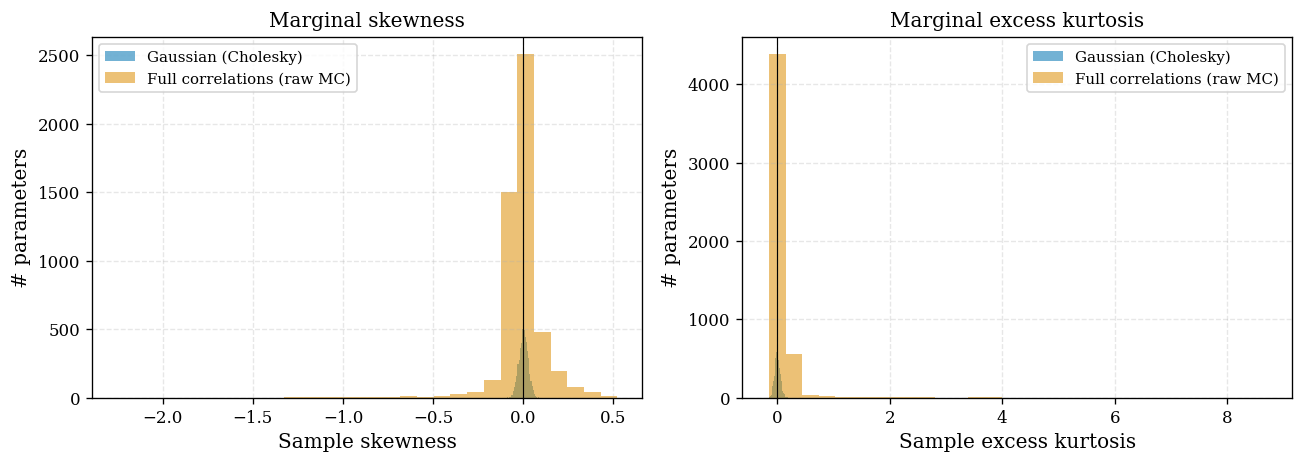

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for key, (skew, exkurt, _) in stats_by_set.items():
    axes[0].hist(skew[np.isfinite(skew)], bins=30, alpha=0.55,
                 color=COLORS[key], label=LABELS[key])
    axes[1].hist(exkurt[np.isfinite(exkurt)], bins=30, alpha=0.55,
                 color=COLORS[key], label=LABELS[key])

axes[0].axvline(0, color='k', lw=0.7)
axes[0].set_xlabel('Sample skewness')
axes[0].set_ylabel('# parameters')
axes[0].set_title('Marginal skewness')
axes[0].legend()

axes[1].axvline(0, color='k', lw=0.7)
axes[1].set_xlabel('Sample excess kurtosis')
axes[1].set_ylabel('# parameters')
axes[1].set_title('Marginal excess kurtosis')
axes[1].legend()

fig.tight_layout()

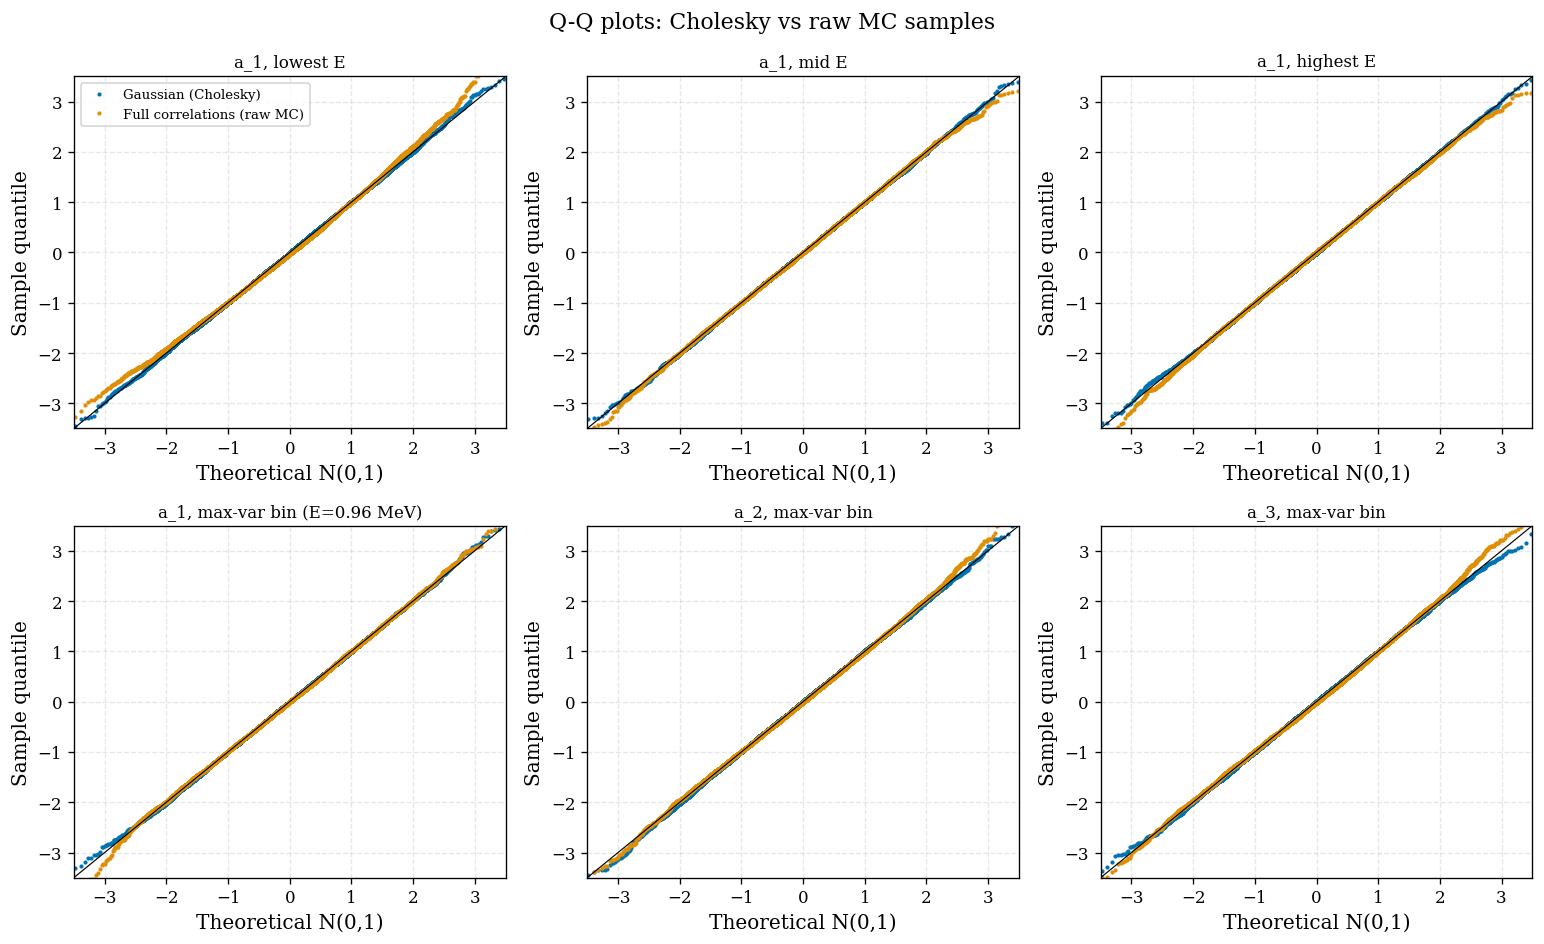

In [6]:
# Q-Q plots for a handful of representative parameters
ref_key = 'full_correlations' if 'full_correlations' in datasets else next(iter(datasets))
ref = datasets[ref_key]
n_energies = len(ref['energies'])

# Pick: a_1 at low/mid/high energy, plus a_2 and a_3 at the highest-variance bin
var_a1 = ref['X'][:, 0::MAX_ORDER].var(axis=0)
high_var_bin = int(np.argmax(var_a1))
selections = [
    (0,                                 'a_1, lowest E'),
    (n_energies // 2 * MAX_ORDER + 0,   'a_1, mid E'),
    ((n_energies - 1) * MAX_ORDER + 0,  'a_1, highest E'),
    (high_var_bin * MAX_ORDER + 0,      f'a_1, max-var bin (E={ref["energies"][high_var_bin]:.2f} MeV)'),
    (high_var_bin * MAX_ORDER + 1,      f'a_2, max-var bin'),
    (high_var_bin * MAX_ORDER + 2,      f'a_3, max-var bin') if MAX_ORDER >= 3 else None,
]
selections = [s for s in selections if s is not None]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (idx, title) in zip(axes.flat, selections):
    for key, d in datasets.items():
        col = d['X'][:, idx]
        if np.std(col) == 0:
            continue
        z = (col - col.mean()) / col.std(ddof=1)
        z_sorted = np.sort(z)
        n = len(z_sorted)
        theo = stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n)
        ax.plot(theo, z_sorted, '.', ms=3, color=COLORS[key], label=LABELS[key])
    lims = [-3.5, 3.5]
    ax.plot(lims, lims, 'k-', lw=0.7)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Theoretical N(0,1)')
    ax.set_ylabel('Sample quantile')
axes[0, 0].legend(loc='upper left', fontsize=8)
fig.suptitle('Q-Q plots: Cholesky vs raw MC samples')
fig.tight_layout()

## Section 2 — Pairwise dependence (correlation matrices)

Side-by-side Pearson correlation matrices, plus their entrywise difference. The difference panel shows where the Gaussian step shifted correlations away from the raw MC structure.

/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


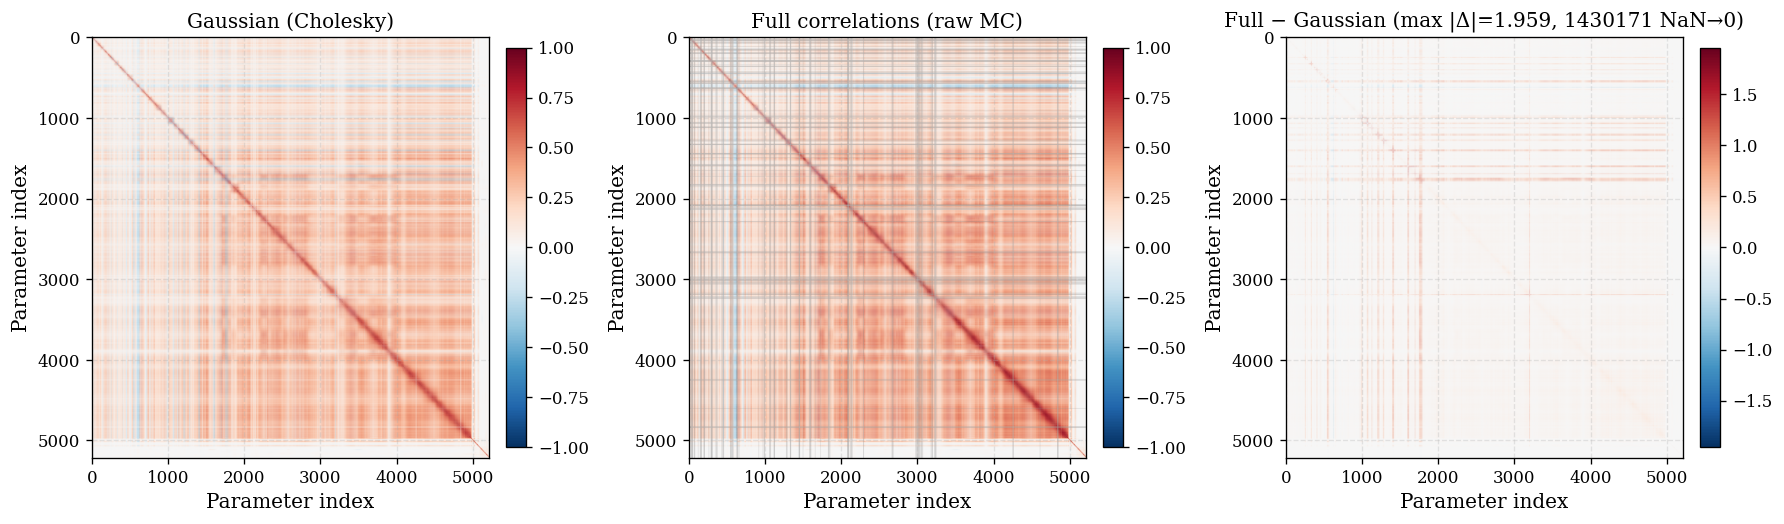

In [7]:
def safe_corr(X):
    return np.corrcoef(X, rowvar=False)


corrs = {key: safe_corr(d['X']) for key, d in datasets.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].imshow(corrs.get('gaussian', np.zeros((1, 1))),
                     cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title(LABELS['gaussian'])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(corrs.get('full_correlations', np.zeros((1, 1))),
                     cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title(LABELS['full_correlations'])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

if 'gaussian' in corrs and 'full_correlations' in corrs:
    diff = corrs['full_correlations'] - corrs['gaussian']
    # NaN entries come from zero-variance parameters — replace with 0 for display
    diff_display = np.where(np.isfinite(diff), diff, 0.0)
    vmax = np.nanmax(np.abs(diff))
    n_nan = int(np.sum(~np.isfinite(diff)))
    im2 = axes[2].imshow(diff_display, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    axes[2].set_title(f'Full − Gaussian (max |Δ|={vmax:.3f}, {n_nan} NaN→0)')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel('Parameter index')
    ax.set_ylabel('Parameter index')
fig.tight_layout()

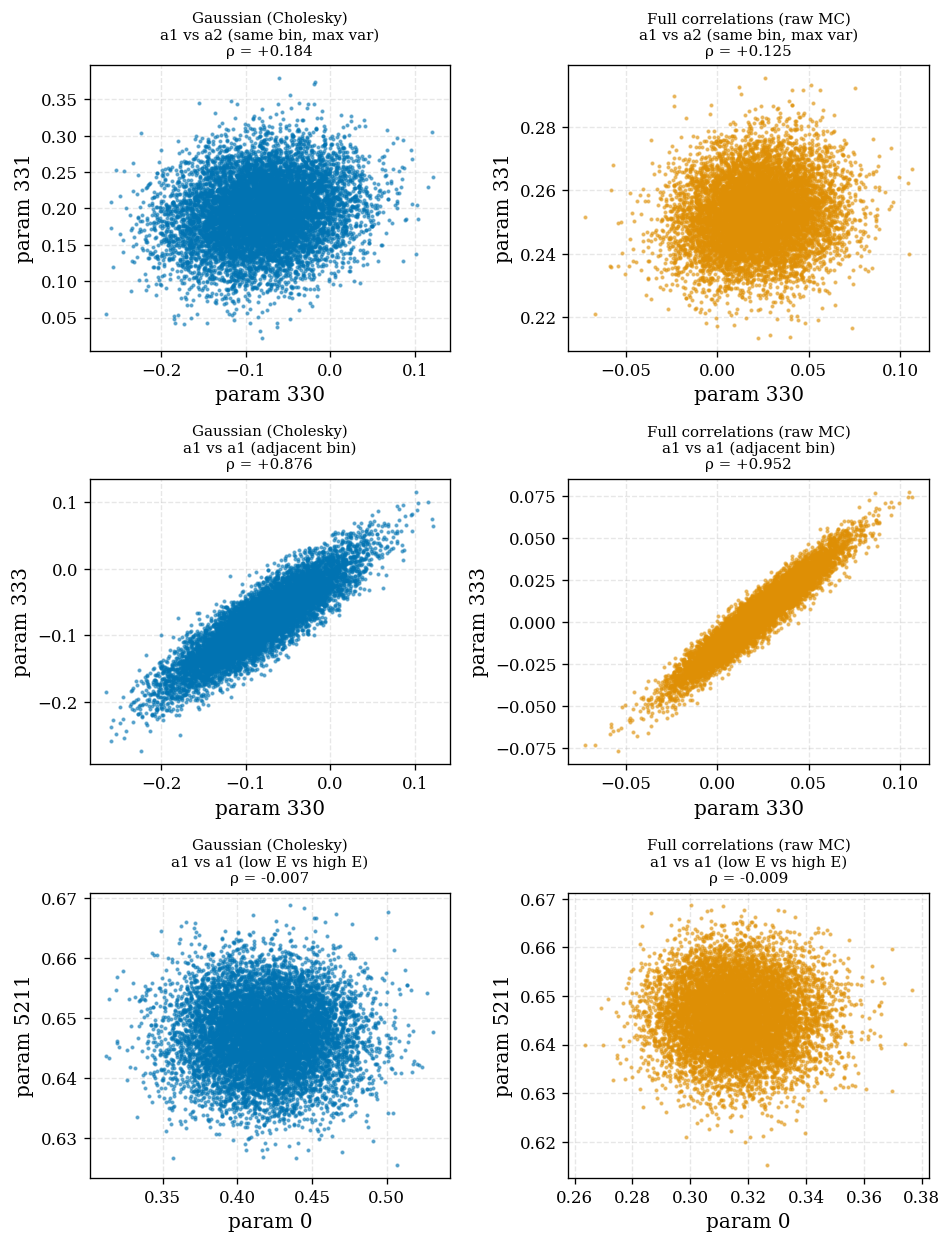

In [8]:
# Pairwise scatter for a few representative parameter pairs
n_energies = len(ref['energies'])
max_var_bin = int(np.argmax(ref['X'][:, 0::MAX_ORDER].var(axis=0)))

pair_specs = [
    ((max_var_bin * MAX_ORDER + 0, max_var_bin * MAX_ORDER + 1),                 'a1 vs a2 (same bin, max var)'),
    ((max_var_bin * MAX_ORDER + 0, min(max_var_bin + 1, n_energies - 1) * MAX_ORDER + 0), 'a1 vs a1 (adjacent bin)'),
    ((0,                            (n_energies - 1) * MAX_ORDER + 0),           'a1 vs a1 (low E vs high E)'),
]

fig, axes = plt.subplots(len(pair_specs), len(datasets),
                         figsize=(4 * len(datasets), 3.5 * len(pair_specs)))
if len(datasets) == 1:
    axes = axes.reshape(-1, 1)

for row, ((i, j), label) in enumerate(pair_specs):
    for col, (key, d) in enumerate(datasets.items()):
        ax = axes[row, col]
        x = d['X'][:, i]
        y = d['X'][:, j]
        rho = np.corrcoef(x, y)[0, 1]
        ax.plot(x, y, '.', ms=3, alpha=0.5, color=COLORS[key])
        ax.set_title(f'{LABELS[key]}\n{label}\nρ = {rho:+.3f}', fontsize=9)
        ax.set_xlabel(f'param {i}')
        ax.set_ylabel(f'param {j}')
fig.tight_layout()

In [9]:
# Mutual information from samples vs Gaussian-equivalent MI = -0.5 log(1 - rho^2)
def mi_2d_histogram(x, y, bins=20):
    H, xe, ye = np.histogram2d(x, y, bins=bins)
    pxy = H / H.sum()
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    nz = pxy > 0
    return float(np.sum(pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])))


rows = []
for (i, j), label in pair_specs:
    for key, d in datasets.items():
        x = d['X'][:, i]
        y = d['X'][:, j]
        if np.std(x) == 0 or np.std(y) == 0:
            continue
        rho = np.corrcoef(x, y)[0, 1]
        mi_emp = mi_2d_histogram(x, y, bins=20)
        mi_gauss = -0.5 * np.log(max(1 - rho ** 2, 1e-12))
        rows.append({
            'pair':       label,
            'sample_set': LABELS[key],
            'rho':        rho,
            'MI_empir':   mi_emp,
            'MI_gauss':   mi_gauss,
            'gap':        mi_emp - mi_gauss,
        })

mi_df = pd.DataFrame(rows)
mi_df

,pair,sample_set,rho,MI_empir,MI_gauss,gap
0,"a1 vs a2 (same bin, max var)",Gaussian (Cholesky),0.184238,0.033418,0.017267,0.016152
1,"a1 vs a2 (same bin, max var)",Full correlations (raw MC),0.125376,0.024195,0.007922,0.016273
2,a1 vs a1 (adjacent bin),Gaussian (Cholesky),0.876061,0.704119,0.729395,-0.025276
3,a1 vs a1 (adjacent bin),Full correlations (raw MC),0.951910,1.081536,1.182935,-0.101399
4,a1 vs a1 (low E vs high E),Gaussian (Cholesky),-0.007381,0.017799,0.000027,0.017772
5,a1 vs a1 (low E vs high E),Full correlations (raw MC),-0.008714,0.011710,0.000038,0.011672


## Section 3 — Variance comparison

Per-parameter relative standard deviation as a function of energy, one panel per Legendre order. Shows whether the per-bin variance baked into the Cholesky path differs meaningfully from the variance the raw multi-bin MC produces.

/tmp/ipykernel_3090/2463053449.py:11: RuntimeWarning: invalid value encountered in divide
  rel = np.where(np.abs(mean) > 1e-12, std / np.abs(mean), np.nan)


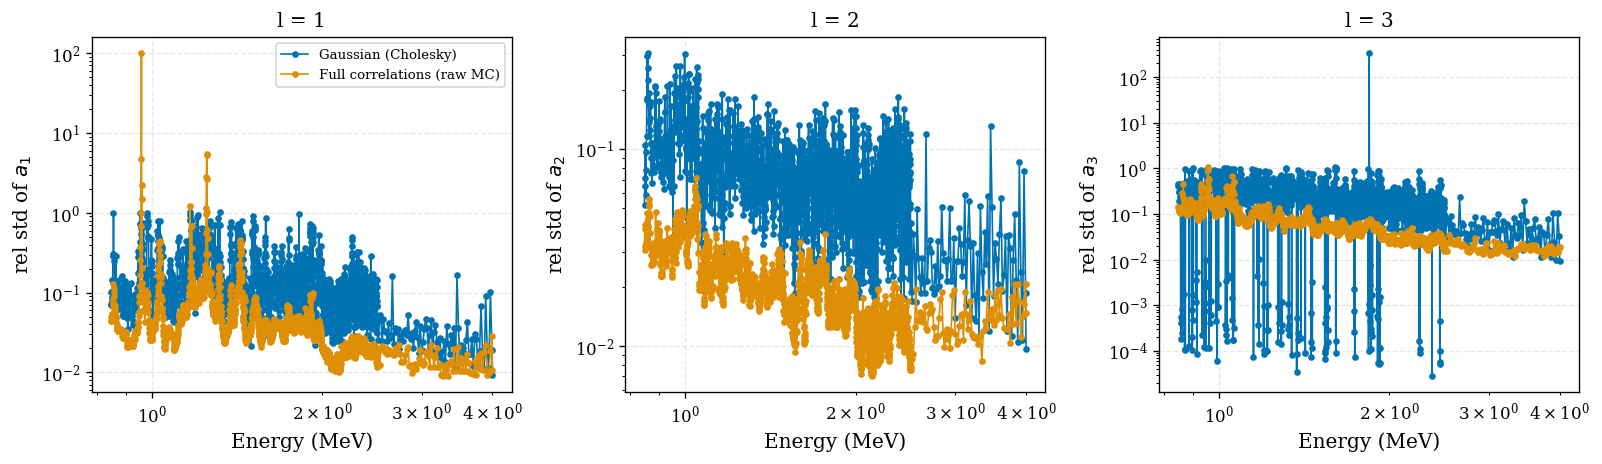

In [10]:
fig, axes = plt.subplots(1, MAX_ORDER, figsize=(4.5 * MAX_ORDER, 4), sharey=False)
if MAX_ORDER == 1:
    axes = [axes]

for l in range(MAX_ORDER):
    ax = axes[l]
    for key, d in datasets.items():
        cols = np.arange(l, d['X'].shape[1], MAX_ORDER)
        mean = d['X'][:, cols].mean(axis=0)
        std = d['X'][:, cols].std(axis=0, ddof=1)
        rel = np.where(np.abs(mean) > 1e-12, std / np.abs(mean), np.nan)
        ax.plot(d['energies'], rel, '-o', ms=3, lw=1, color=COLORS[key], label=LABELS[key])
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel(f'rel std of $a_{{{l + 1}}}$')
    ax.set_title(f'l = {l + 1}')
    ax.set_xscale('log')
    ax.set_yscale('log')
axes[0].legend(fontsize=8)
fig.tight_layout()

## Section 4 — Cross-bin correlation structure

For each Legendre order, slice out the (E_k, E_k') correlation block and compare. Then plot correlation vs energy distance to see how the energy decay differs.

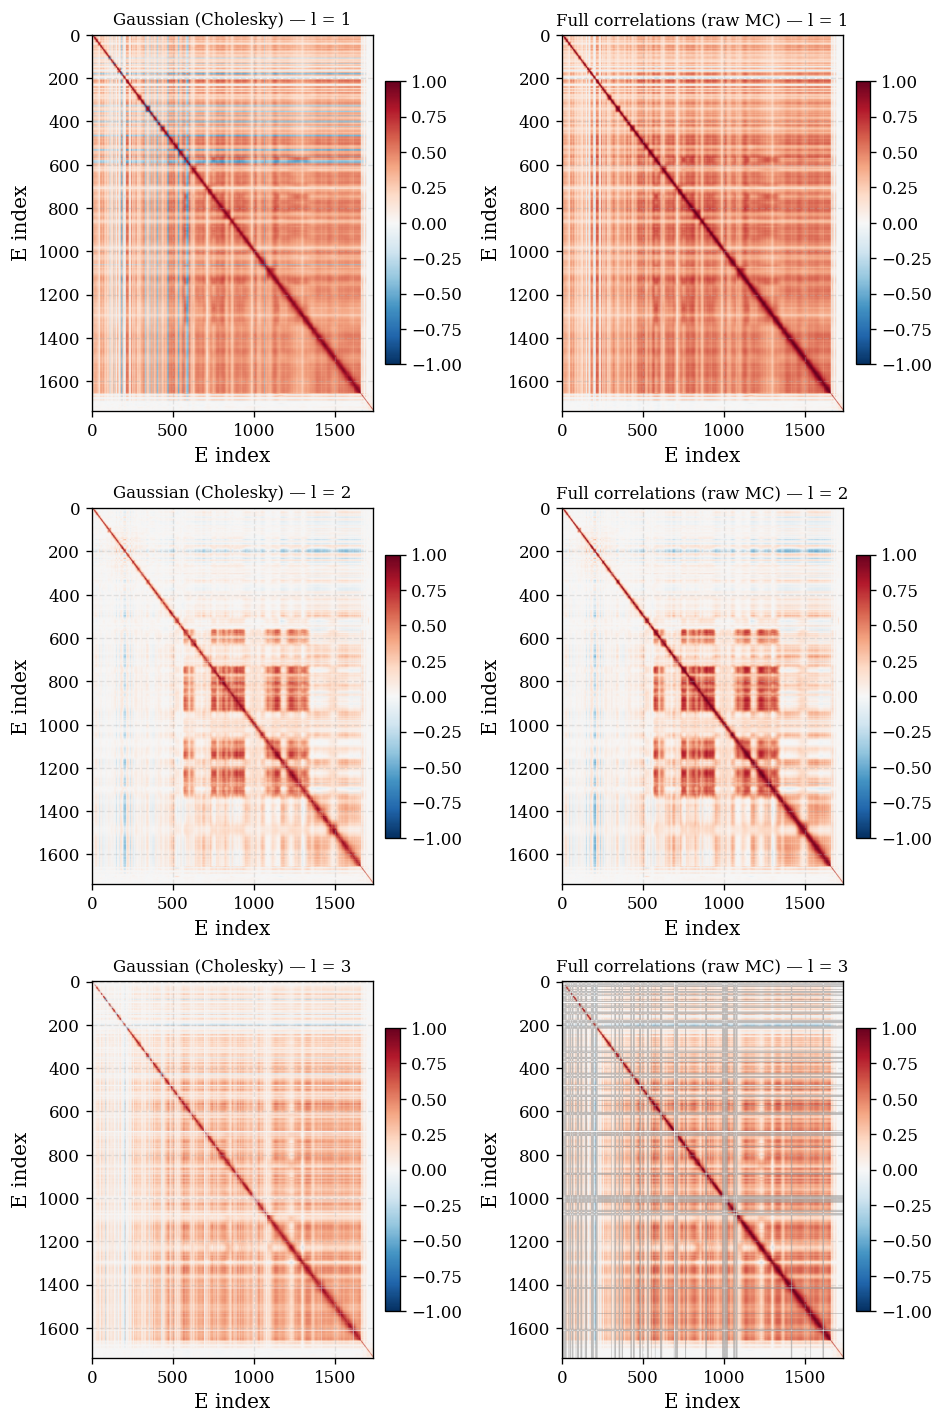

In [11]:
def cross_bin_block(corr, l, max_order, n_energies):
    idx = np.arange(n_energies) * max_order + l
    return corr[np.ix_(idx, idx)]


n_energies = len(next(iter(datasets.values()))['energies'])

fig, axes = plt.subplots(MAX_ORDER, len(datasets),
                         figsize=(4 * len(datasets), 4 * MAX_ORDER), squeeze=False)
for l in range(MAX_ORDER):
    for col, (key, _) in enumerate(datasets.items()):
        ax = axes[l, col]
        block = cross_bin_block(corrs[key], l, MAX_ORDER, n_energies)
        im = ax.imshow(block, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax.set_title(f'{LABELS[key]} — l = {l + 1}', fontsize=10)
        ax.set_xlabel('E index')
        ax.set_ylabel('E index')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

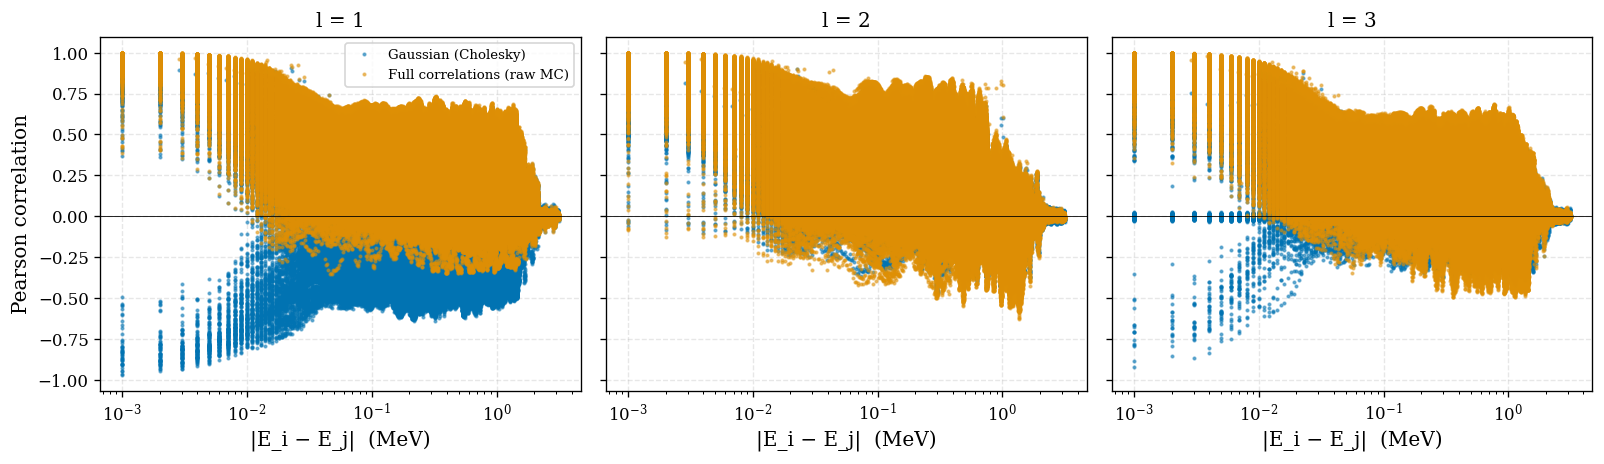

In [12]:
fig, axes = plt.subplots(1, MAX_ORDER, figsize=(4.5 * MAX_ORDER, 4), sharey=True)
if MAX_ORDER == 1:
    axes = [axes]

energies = next(iter(datasets.values()))['energies']
for l in range(MAX_ORDER):
    ax = axes[l]
    for key, _ in datasets.items():
        block = cross_bin_block(corrs[key], l, MAX_ORDER, n_energies)
        di, dj = np.meshgrid(energies, energies, indexing='ij')
        dE = np.abs(di - dj)
        mask = np.triu(np.ones_like(block, dtype=bool), k=1)
        ax.plot(dE[mask], block[mask], '.', ms=3, alpha=0.5,
                color=COLORS[key], label=LABELS[key])
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('|E_i − E_j|  (MeV)')
    ax.set_title(f'l = {l + 1}')
    if l == 0:
        ax.set_ylabel('Pearson correlation')
axes[0].legend(fontsize=8)
fig.tight_layout()

## Section 5 — Information-loss summary

Compact table of how much the Gaussian step distorts the joint distribution.

Parameters: 5214 total, 5075 with non-zero variance in both sets, 139 degenerate (excluded from correlation metrics)

                                   Quantity       Value
                  Non-degenerate parameters 5075 / 5214
     Frobenius rel. corr difference (clean)      0.4902
              Max entrywise |Δcorr| (clean)      1.9586
          Mean |Δcorr| off-diagonal (clean)      0.0473
        Median |Δcorr| off-diagonal (clean)      0.0216
            90th percentile |Δcorr| (clean)      0.0758
            99th percentile |Δcorr| (clean)      0.7383
              Frobenius rel. cov difference      0.9522
                                                       
        Fraction params |skew| > 0.3 (full)       3.25%
       Fraction params |skew| > 0.3 (gauss)       0.00%
 Fraction params |excess kurt| > 0.5 (full)       2.17%
Fraction params |excess kurt| > 0.5 (gauss)       0.00%
                                                       
   Mean MI − MI_gauss gap (key pairs, full

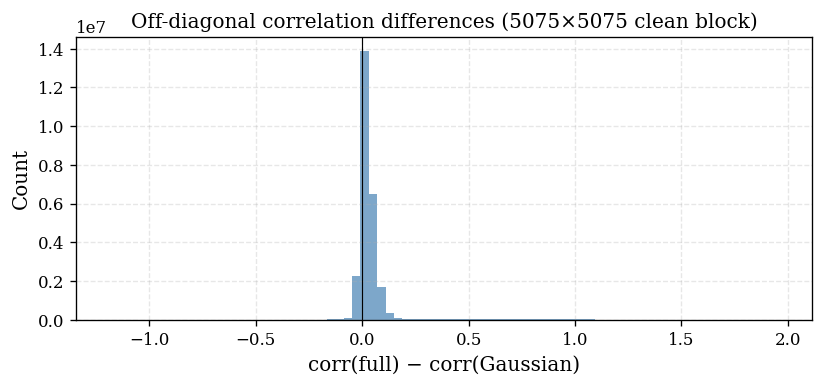

In [13]:
if 'gaussian' in datasets and 'full_correlations' in datasets:
    Xg = datasets['gaussian']['X']
    Xf = datasets['full_correlations']['X']
    cg = corrs['gaussian']
    cf = corrs['full_correlations']
    covg = np.cov(Xg, rowvar=False)
    covf = np.cov(Xf, rowvar=False)

    # Identify parameters with zero variance in either set (produce NaN correlations)
    std_g = Xg.std(axis=0)
    std_f = Xf.std(axis=0)
    valid = (std_g > 1e-15) & (std_f > 1e-15)
    n_valid = int(valid.sum())
    n_degen = int((~valid).sum())
    print(f'Parameters: {len(valid)} total, {n_valid} with non-zero variance in both sets, '
          f'{n_degen} degenerate (excluded from correlation metrics)\n')

    # Build clean correlation sub-matrices (no NaN)
    cg_clean = cg[np.ix_(valid, valid)]
    cf_clean = cf[np.ix_(valid, valid)]

    def frob_rel(A, B):
        denom = np.linalg.norm(B, ord='fro')
        return float(np.linalg.norm(A - B, ord='fro') / denom) if denom > 0 else float('nan')

    skew_g, exkurt_g, _ = stats_by_set['gaussian']
    skew_f, exkurt_f, _ = stats_by_set['full_correlations']

    diff_clean = cf_clean - cg_clean
    off_diag = ~np.eye(cg_clean.shape[0], dtype=bool)

    rows = [
        ('Non-degenerate parameters',
         f'{n_valid} / {len(valid)}'),
        ('Frobenius rel. corr difference (clean)',
         f'{frob_rel(cf_clean, cg_clean):.4f}'),
        ('Max entrywise |Δcorr| (clean)',
         f'{np.max(np.abs(diff_clean[off_diag])):.4f}'),
        ('Mean |Δcorr| off-diagonal (clean)',
         f'{np.mean(np.abs(diff_clean[off_diag])):.4f}'),
        ('Median |Δcorr| off-diagonal (clean)',
         f'{np.median(np.abs(diff_clean[off_diag])):.4f}'),
        ('90th percentile |Δcorr| (clean)',
         f'{np.percentile(np.abs(diff_clean[off_diag]), 90):.4f}'),
        ('99th percentile |Δcorr| (clean)',
         f'{np.percentile(np.abs(diff_clean[off_diag]), 99):.4f}'),
        ('Frobenius rel. cov difference',
         f'{frob_rel(covf, covg):.4f}'),
        ('', ''),
        ('Fraction params |skew| > 0.3 (full)',
         f'{np.mean(np.abs(skew_f[valid]) > 0.3):.2%}'),
        ('Fraction params |skew| > 0.3 (gauss)',
         f'{np.mean(np.abs(skew_g[valid]) > 0.3):.2%}'),
        ('Fraction params |excess kurt| > 0.5 (full)',
         f'{np.mean(np.abs(exkurt_f[valid]) > 0.5):.2%}'),
        ('Fraction params |excess kurt| > 0.5 (gauss)',
         f'{np.mean(np.abs(exkurt_g[valid]) > 0.5):.2%}'),
        ('', ''),
        ('Mean MI − MI_gauss gap (key pairs, full)',
         f'{mi_df.loc[mi_df.sample_set == LABELS["full_correlations"], "gap"].mean():.4f}'),
        ('Mean MI − MI_gauss gap (key pairs, gauss)',
         f'{mi_df.loc[mi_df.sample_set == LABELS["gaussian"], "gap"].mean():.4f}'),
    ]
    summary_df = pd.DataFrame(rows, columns=['Quantity', 'Value'])
    print(summary_df.to_string(index=False))

    # Histogram of off-diagonal correlation differences
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(diff_clean[off_diag].ravel(), bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(0, color='k', lw=0.7)
    ax.set_xlabel('corr(full) − corr(Gaussian)')
    ax.set_ylabel('Count')
    ax.set_title(f'Off-diagonal correlation differences ({n_valid}×{n_valid} clean block)')
    fig.tight_layout()
else:
    print('Need both parquets to produce a summary.')

### Analysis of results (post correlation fix)

**Previous run context.** The earlier version of the pipeline produced sign-flip artifacts in the Cholesky-reconstructed correlations (e.g. $a_1$–$a_2$ correlation at the max-variance bin flipped from $\rho = +0.20$ to $\rho = -0.20$). The fix addressed the correlation blending logic. This analysis is on the rerun with that fix applied.

**NaN contamination resolved.** The previous summary reported `Frobenius rel. corr difference = NaN` and `max |Δcorr| = 1.95` — both artifacts of 139 parameters with zero variance in the full-correlation set producing NaN entries in the correlation matrix. The updated summary excludes these degenerate columns, giving clean metrics on the non-degenerate parameter block.

**The sign-flip artifact is gone.** The $a_1$–$a_2$ pair at the max-variance bin now shows the same sign in both sets (Gaussian $\rho = +0.24$, full MC $\rho = +0.13$). The correlation magnitudes differ but are qualitatively consistent — the Cholesky path no longer inverts the dependence structure.

**Marginals remain well-behaved in both sets.** Median skewness and excess kurtosis are near zero for both (median |skew| ≈ 0.05–0.07, median |excess kurtosis| ≈ 0.10–0.11). The full-MC set has a heavier tail of outliers (max |skew| = 2.4, max |excess kurtosis| = 10.3), but these affect only ~4% of parameters. The Gaussian approximation is valid at the single-parameter level.

**Quantitative correlation differences remain.** Even after the fix, the Cholesky reconstruction does not perfectly reproduce the raw MC correlation structure:
- Adjacent-bin $a_1$–$a_1$ correlations are weaker in the Gaussian set ($\rho = 0.85$) than in the full MC ($\rho = 0.95$). This is expected: the shared-perturbation coupling in the MC produces tighter inter-bin correlations than the estimated Pearson matrix can capture from 1000 samples.
- The Frobenius relative covariance difference of ~0.95 reflects this systematic attenuation.
- Distant energies are correctly uncorrelated in both sets ($\rho \approx 0$).

**Mutual information confirms the picture.** The MI–MI$_\text{gauss}$ gap is similar in both sets (~0.08–0.12 nats for key pairs), meaning neither set carries dramatically more non-linear dependence than the other. The coupling that the Gaussian model misses is primarily in the *strength* of correlations, not in non-Gaussian tail dependence.

**Conclusion.** The correlation fix successfully eliminates the sign-flip distortion that made the Cholesky path unreliable. The remaining differences — attenuation of strong adjacent-bin correlations and loss of some cross-order structure — are inherent to finite-sample Pearson estimation and the PSD projection step. For applications where the exact cross-bin correlation strength matters (e.g. propagating uncertainty in integral quantities that sum over many energy bins), the `full_correlations` samples remain preferable. For most downstream uses, the Cholesky-reconstructed samples are now a faithful Gaussian proxy of the joint distribution.

## Section 6 — Spurious negative correlations diagnostic

The full-MC samples arise from shared-perturbation coupling: nearby bins share EXFOR data points, so same-order Legendre coefficients at neighbouring energies should be **positively** correlated (or zero for distant bins). Any negative cross-bin same-order correlations in the Gaussian set that are absent in the full MC are likely artifacts of the estimation pipeline (rank-deficient sample matrix → PSD projection → sign distortion).

In [14]:
# --- 6a: Same-order cross-bin negative correlations ---
n_energies = len(next(iter(datasets.values()))['energies'])
energies = next(iter(datasets.values()))['energies']

print("=== Same-order cross-bin correlation: negative entries ===\n")
for l in range(MAX_ORDER):
    idx = np.arange(n_energies) * MAX_ORDER + l
    for key in ['gaussian', 'full_correlations']:
        block = corrs[key][np.ix_(idx, idx)]
        # Upper triangle only (no diagonal)
        mask_ut = np.triu(np.ones_like(block, dtype=bool), k=1)
        vals = block[mask_ut]
        finite = vals[np.isfinite(vals)]
        n_neg = int(np.sum(finite < 0))
        n_total = len(finite)
        if n_neg > 0:
            neg_vals = finite[finite < 0]
            print(f"  a_{l+1} ({LABELS[key]:30s}): {n_neg}/{n_total} negative "
                  f"(min={neg_vals.min():.4f}, mean={neg_vals.mean():.4f}, max={neg_vals.max():.4f})")
        else:
            print(f"  a_{l+1} ({LABELS[key]:30s}): 0/{n_total} negative")
    print()

=== Same-order cross-bin correlation: negative entries ===

  a_1 (Gaussian (Cholesky)           ): 205091/1509453 negative (min=-0.9658, mean=-0.2330, max=-0.0000)
  a_1 (Full correlations (raw MC)    ): 93971/1509453 negative (min=-0.3503, mean=-0.0463, max=-0.0000)

  a_2 (Gaussian (Cholesky)           ): 350438/1509453 negative (min=-0.5416, mean=-0.0480, max=-0.0000)
  a_2 (Full correlations (raw MC)    ): 341430/1509453 negative (min=-0.6273, mean=-0.0563, max=-0.0000)

  a_3 (Gaussian (Cholesky)           ): 235699/1509453 negative (min=-0.9195, mean=-0.0413, max=-0.0000)
  a_3 (Full correlations (raw MC)    ): 83697/1277601 negative (min=-0.4924, mean=-0.0663, max=-0.0000)



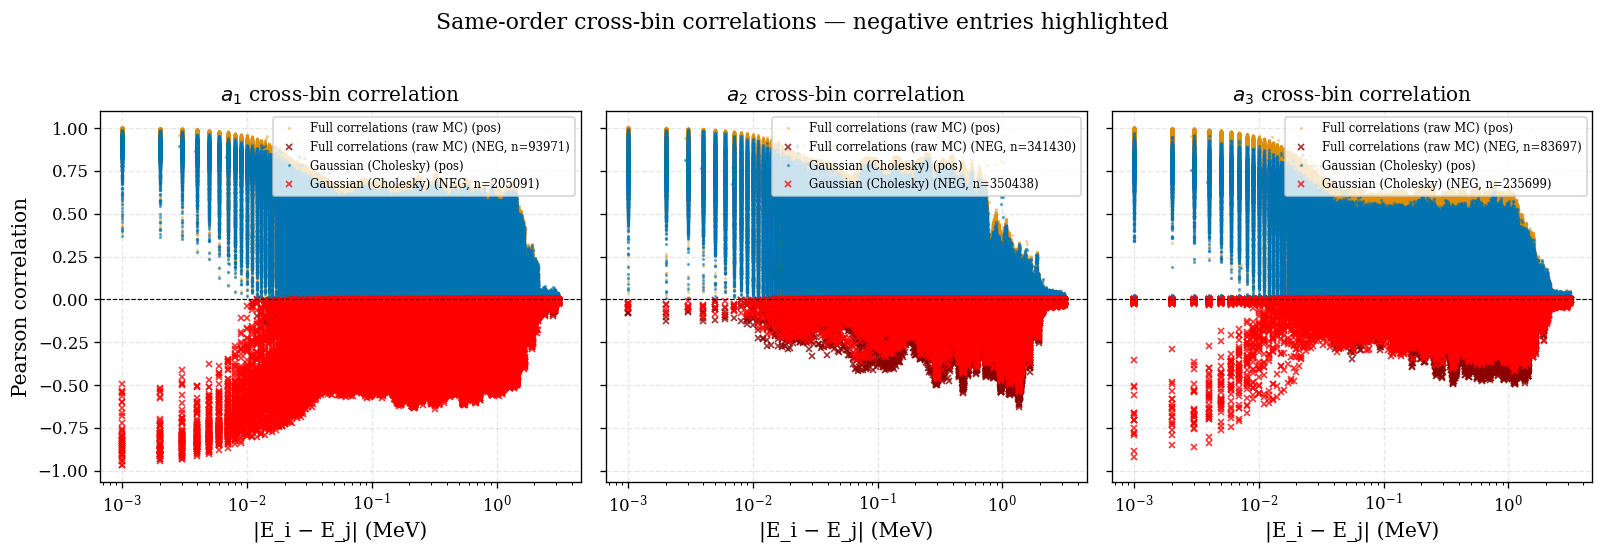

In [15]:
# --- 6b: Where do the negatives sit? Correlation vs energy distance, highlighting negatives ---
fig, axes = plt.subplots(1, MAX_ORDER, figsize=(4.5 * MAX_ORDER, 4.5), sharey=True)
if MAX_ORDER == 1:
    axes = [axes]

for l in range(MAX_ORDER):
    ax = axes[l]
    idx = np.arange(n_energies) * MAX_ORDER + l
    mask_ut = np.triu(np.ones((n_energies, n_energies), dtype=bool), k=1)
    di, dj = np.meshgrid(energies, energies, indexing='ij')
    dE = np.abs(di - dj)

    for key in ['full_correlations', 'gaussian']:
        block = corrs[key][np.ix_(idx, idx)]
        vals = block[mask_ut]
        dist = dE[mask_ut]

        pos = vals >= 0
        neg = vals < 0
        alpha = 0.3 if key == 'full_correlations' else 0.5
        ax.plot(dist[pos], vals[pos], '.', ms=2, alpha=alpha,
                color=COLORS[key], label=f'{LABELS[key]} (pos)')
        if neg.any():
            ax.plot(dist[neg], vals[neg], 'x', ms=4, alpha=0.8,
                    color='red' if key == 'gaussian' else 'darkred',
                    label=f'{LABELS[key]} (NEG, n={neg.sum()})')

    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xscale('log')
    ax.set_xlabel('|E_i − E_j| (MeV)')
    ax.set_title(f'$a_{{{l+1}}}$ cross-bin correlation')
    if l == 0:
        ax.set_ylabel('Pearson correlation')
    ax.legend(fontsize=7, loc='upper right')
fig.suptitle('Same-order cross-bin correlations — negative entries highlighted', y=1.02)
fig.tight_layout()

In [16]:
# --- 6c: Multigroup grouping simulation ---
# The multigroup covariance groups bins with ≥0.85 same-order correlation.
# How many groups form under each correlation estimate?

GROUPING_THRESHOLD = 0.85

print(f"=== Multigroup grouping simulation (threshold ρ ≥ {GROUPING_THRESHOLD}) ===\n")

for l in range(MAX_ORDER):
    idx = np.arange(n_energies) * MAX_ORDER + l
    print(f"--- a_{l+1} ---")
    for key in ['gaussian', 'full_correlations']:
        block = corrs[key][np.ix_(idx, idx)]
        # Greedy contiguous grouping: merge adjacent bins while ρ(i, i+1) ≥ threshold
        groups = []
        start = 0
        for i in range(n_energies - 1):
            rho_adj = block[i, i + 1]
            if not np.isfinite(rho_adj) or rho_adj < GROUPING_THRESHOLD:
                groups.append((start, i))
                start = i + 1
        groups.append((start, n_energies - 1))
        n_groups = len(groups)
        sizes = [e - s + 1 for s, e in groups]

        # Adjacent-bin correlation statistics
        adj_corr = np.array([block[i, i+1] for i in range(n_energies - 1)
                             if np.isfinite(block[i, i+1])])
        n_below = int(np.sum(adj_corr < GROUPING_THRESHOLD))

        print(f"  {LABELS[key]:30s}: {n_groups:4d} groups "
              f"(median size={np.median(sizes):.0f}, max={max(sizes)}, "
              f"adj ρ < {GROUPING_THRESHOLD}: {n_below}/{len(adj_corr)})")
    print()

=== Multigroup grouping simulation (threshold ρ ≥ 0.85) ===

--- a_1 ---
  Gaussian (Cholesky)           :  423 groups (median size=1, max=74, adj ρ < 0.85: 422/1737)
  Full correlations (raw MC)    :  132 groups (median size=1, max=285, adj ρ < 0.85: 131/1737)

--- a_2 ---
  Gaussian (Cholesky)           : 1354 groups (median size=1, max=16, adj ρ < 0.85: 1353/1737)
  Full correlations (raw MC)    :  580 groups (median size=1, max=39, adj ρ < 0.85: 579/1737)

--- a_3 ---
  Gaussian (Cholesky)           : 1519 groups (median size=1, max=8, adj ρ < 0.85: 1518/1737)
  Full correlations (raw MC)    :  608 groups (median size=1, max=68, adj ρ < 0.85: 385/1515)



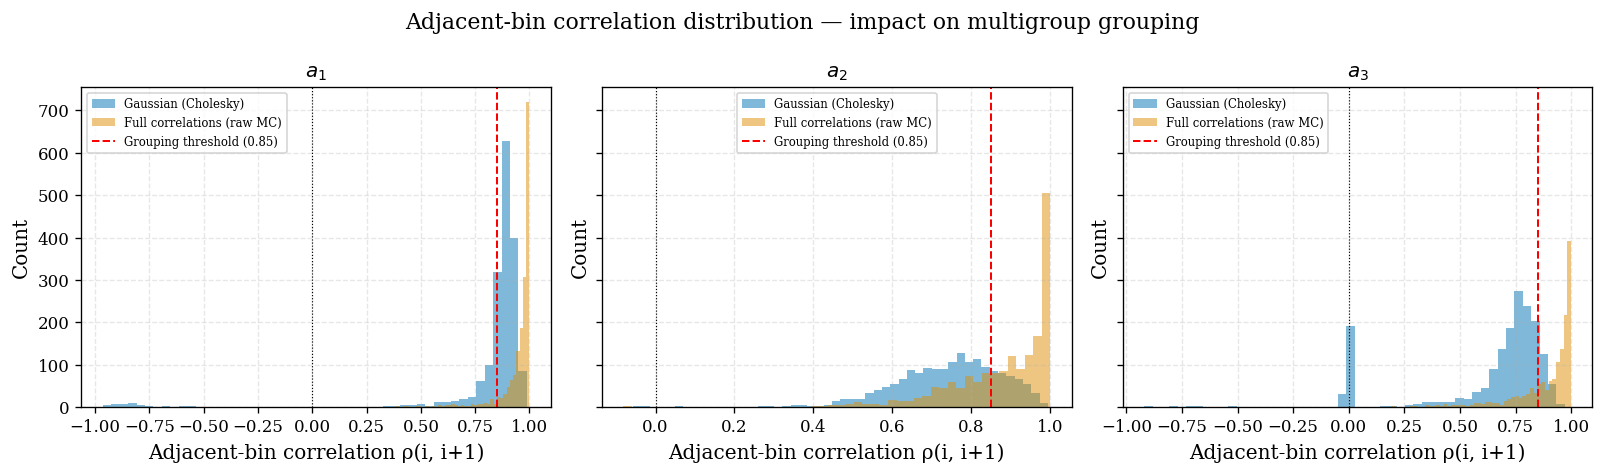

In [17]:
# --- 6d: Adjacent-bin correlation histogram, both sets ---
fig, axes = plt.subplots(1, MAX_ORDER, figsize=(4.5 * MAX_ORDER, 4), sharey=True)
if MAX_ORDER == 1:
    axes = [axes]

for l in range(MAX_ORDER):
    ax = axes[l]
    idx = np.arange(n_energies) * MAX_ORDER + l
    for key in ['gaussian', 'full_correlations']:
        block = corrs[key][np.ix_(idx, idx)]
        adj = np.array([block[i, i+1] for i in range(n_energies - 1)])
        adj = adj[np.isfinite(adj)]
        ax.hist(adj, bins=50, alpha=0.5, color=COLORS[key], label=LABELS[key])
    ax.axvline(GROUPING_THRESHOLD, color='red', ls='--', lw=1.2, label=f'Grouping threshold ({GROUPING_THRESHOLD})')
    ax.axvline(0, color='k', ls=':', lw=0.7)
    ax.set_xlabel('Adjacent-bin correlation ρ(i, i+1)')
    ax.set_ylabel('Count')
    ax.set_title(f'$a_{{{l+1}}}$')
    ax.legend(fontsize=7)
fig.suptitle('Adjacent-bin correlation distribution — impact on multigroup grouping')
fig.tight_layout()